# Bloque I — Análisis de Ventas Anuales 2026

**Duración estimada:** 3 horas  
**Modalidad:** explicación + demostración guiada + práctica individual  
**Dataset:** `../data/ventas_*_2026.csv` (12 archivos mensuales)

## Objetivo de aprendizaje

Al finalizar la sesión, el alumnado será capaz de cargar, limpiar, transformar, describir y visualizar un dataset anual tabular con Python y `pandas`, generando conclusiones iniciales útiles para un proyecto de análisis de datos a nivel anual.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:20 | Ecosistema Python para análisis de datos |
| 0:20–0:50 | Repaso de estructuras básicas de Python |
| 0:50–1:25 | Introducción práctica a `numpy` y `pandas` |
| 1:25–1:35 | Pausa |
| 1:35–2:15 | Carga, exploración y limpieza de datos anuales |
| 2:15–2:45 | Análisis descriptivo y visualización anual |
| 2:45–3:00 | Ejercicio integrador anual y conclusiones |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
# Carga de datos anuales
meses = [
    "enero", "febrero", "marzo", "abril", "mayo",
    "junio", "julio", "agosto", "septiembre", "octubre",
    "noviembre", "diciembre"
]

dfs = []
for mes in meses:
    df_mes = pd.read_csv(f"../data/ventas_{mes}_2026.csv")
    dfs.append(df_mes)

df_anual = pd.concat(dfs, ignore_index=True)
df_anual.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe
0,2026-01-23,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,680.880
1,2026-01-04,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,875.988
2,2026-01-12,C1002,Moda,Madrid,Online,7,39.770,0.050,26,266.708
3,2026-01-29,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,306.274
4,2026-01-21,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,NaN,0.090,29,"2,708.835"


In [3]:
print("Filas y columnas del dataset anual:", df_anual.shape)
df_anual.info()

Filas y columnas del dataset anual: (6060, 10)
<class 'pandas.DataFrame'>
RangeIndex: 6060 entries, 0 to 6059
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   fecha                     6060 non-null   str    
 1   cliente_id                6060 non-null   str    
 2   categoria                 6060 non-null   str    
 3   region                    5940 non-null   str    
 4   canal                     6060 non-null   str    
 5   unidades                  6060 non-null   int64  
 6   precio_unitario           5880 non-null   float64
 7   descuento                 6060 non-null   float64
 8   antiguedad_cliente_meses  6060 non-null   int64  
 9   importe                   6060 non-null   float64
dtypes: float64(3), int64(2), str(5)
memory usage: 473.6 KB


In [4]:
# Exploración inicial
display(df_anual.describe(include="all"))
print("\nValores nulos por columna:")
display(df_anual.isnull().sum())
print("\nDuplicados:", df_anual.duplicated().sum())

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe
count,6060,6060,6060,5940,6060,"6,060.000","5,880.000","6,060.000","6,060.000","6,060.000"
unique,372,500,5,5,3,NaN,NaN,NaN,NaN,NaN
top,2026-04-25,C1047,Alimentación,Madrid,Online,NaN,NaN,NaN,NaN,NaN
freq,36,24,1464,1296,2544,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,8.859,136.636,0.069,35.996,"1,226.681"
std,NaN,NaN,NaN,NaN,NaN,2.874,92.821,0.041,20.467,911.864
min,NaN,NaN,NaN,NaN,NaN,2.000,-4.950,0.000,1.000,16.136
25%,NaN,NaN,NaN,NaN,NaN,7.000,56.400,0.040,18.000,507.753
50%,NaN,NaN,NaN,NaN,NaN,9.000,118.305,0.060,36.000,992.780
75%,NaN,NaN,NaN,NaN,NaN,11.000,194.440,0.090,54.000,"1,724.666"



Valores nulos por columna:


fecha                         0
cliente_id                    0
categoria                     0
region                      120
canal                         0
unidades                      0
precio_unitario             180
descuento                     0
antiguedad_cliente_meses      0
importe                       0
dtype: int64


Duplicados: 0


In [7]:
# Limpieza básica
df_anual_limpio = df_anual.copy()

# Eliminar duplicados
df_anual_limpio = df_anual_limpio.drop_duplicates()

# Convertir fecha
df_anual_limpio["fecha"] = pd.to_datetime(df_anual_limpio["fecha"], errors='coerce')

# Imputar nulos
df_anual_limpio["precio_unitario"] = df_anual_limpio["precio_unitario"].fillna(df_anual_limpio["precio_unitario"].median())
df_anual_limpio["region"] = df_anual_limpio["region"].fillna("Sin informar")

# Crear variables derivadas
df_anual_limpio["mes"] = df_anual_limpio["fecha"].dt.month
df_anual_limpio["dia_semana"] = df_anual_limpio["fecha"].dt.day_name()
df_anual_limpio["importe_con_iva"] = df_anual_limpio["importe"] * 1.21
df_anual_limpio["ticket_unitario"] = df_anual_limpio["importe"] / df_anual_limpio["unidades"]

df_anual_limpio.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe,mes,dia_semana,importe_con_iva,ticket_unitario
0,2026-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.070,63,880.059,1.000,Thursday,"1,064.871",110.007
1,2026-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.100,52,"1,046.593",1.000,Friday,"1,266.378",209.319
2,2026-01-03,C1002,Moda,Madrid,Online,7,39.770,0.050,26,319.672,1.000,Saturday,386.804,45.667
3,2026-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.060,53,258.080,1.000,Sunday,312.277,28.676
4,2026-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,118.305,0.090,29,"2,067.083",1.000,Monday,"2,501.170",258.385


In [8]:
# Análisis descriptivo anual
metricas_importe_anual = df_anual_limpio["importe"].agg(["count", "mean", "median", "std", "min", "max"])
metricas_importe_anual

count    6,060.000
mean     1,226.681
median     992.780
std        911.864
min         16.136
max      5,253.611
Name: importe, dtype: float64

In [9]:
ventas_por_categoria_anual = (
    df_anual_limpio
    .groupby("categoria")
    .agg(
        ventas_totales=("importe", "sum"),
        importe_medio=("importe", "mean"),
        unidades_totales=("unidades", "sum"),
        operaciones=("cliente_id", "count")
    )
    .sort_values("ventas_totales", ascending=False)
)

ventas_por_categoria_anual

,ventas_totales,importe_medio,unidades_totales,operaciones
categoria,,,,
Tecnología,"3,320,917.019","2,385.716",12216,1392
Servicios,"1,630,708.222","1,598.734",9288,1020
Hogar,"1,249,261.295","1,084.428",10392,1152
Moda,"685,018.331",663.777,9144,1032
Alimentación,"547,780.425",374.167,12648,1464


In [10]:
ventas_por_region_anual = (
    df_anual_limpio
    .groupby("region")["importe"]
    .sum()
    .sort_values(ascending=False)
)

ventas_por_region_anual

region
Madrid               1,629,445.658
Valencia             1,576,869.670
Andalucía            1,489,765.943
Cataluña             1,268,180.325
Castilla-La Mancha   1,267,139.961
Sin informar           202,283.734
Name: importe, dtype: float64

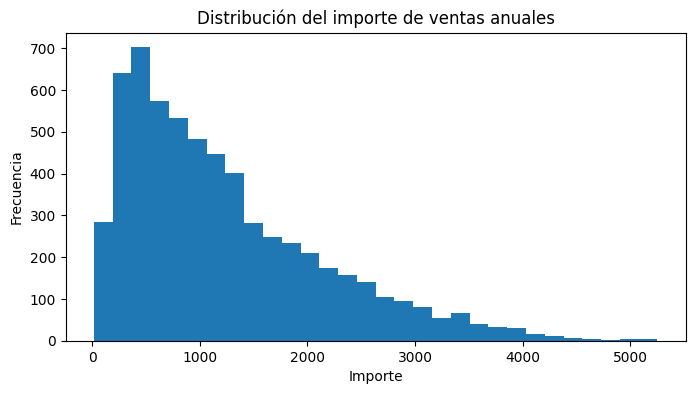

In [11]:
# Visualización anual
plt.figure(figsize=(8, 4))
plt.hist(df_anual_limpio["importe"], bins=30)
plt.title("Distribución del importe de ventas anuales")
plt.xlabel("Importe")
plt.ylabel("Frecuencia")
plt.show()

<Figure size 900x400 with 0 Axes>

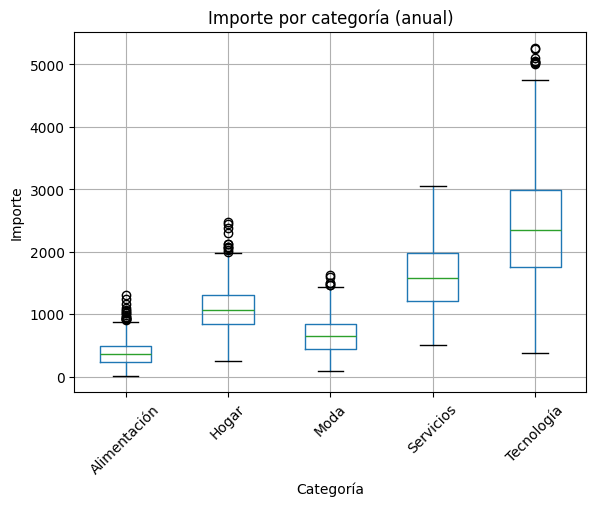

In [12]:
plt.figure(figsize=(9, 4))
df_anual_limpio.boxplot(column="importe", by="categoria", rot=45)
plt.title("Importe por categoría (anual)")
plt.suptitle("")
plt.xlabel("Categoría")
plt.ylabel("Importe")
plt.show()

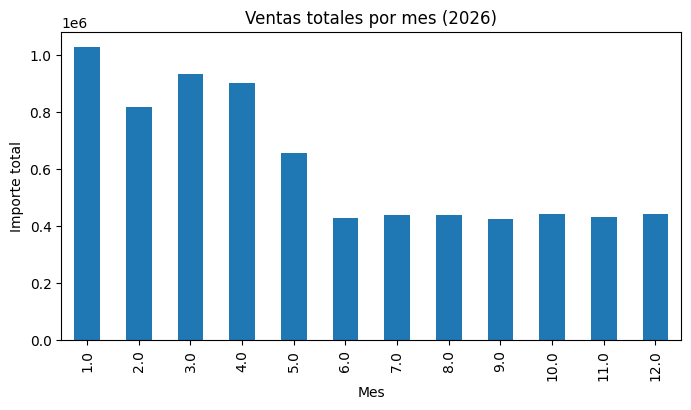

In [13]:
ventas_mes_anual = df_anual_limpio.groupby("mes")["importe"].sum()

plt.figure(figsize=(8, 4))
ventas_mes_anual.plot(kind="bar")
plt.title("Ventas totales por mes (2026)")
plt.xlabel("Mes")
plt.ylabel("Importe total")
plt.show()

In [14]:
# Mini-informe automático anual
categoria_top_anual = ventas_por_categoria_anual.index[0]
region_top_anual = ventas_por_region_anual.index[0]
importe_medio_anual = df_anual_limpio["importe"].mean()

print(f"Conclusión 1: La categoría con mayor venta total anual es {categoria_top_anual}.")
print(f"Conclusión 2: La región con mayor importe acumulado anual es {region_top_anual}.")
print(f"Conclusión 3: El importe medio por operación anual es {importe_medio_anual:,.2f} euros.")

Conclusión 1: La categoría con mayor venta total anual es Tecnología.
Conclusión 2: La región con mayor importe acumulado anual es Madrid.
Conclusión 3: El importe medio por operación anual es 1,226.68 euros.


## 9. Ejercicio integrador anual

Realiza las siguientes tareas para el año completo 2026:

1. Calcula las ventas totales por canal anual.
2. Calcula el ticket medio por región anual.
3. Identifica la categoría con mayor número de unidades vendidas anual.
4. Genera un gráfico de barras con las ventas por canal anual.
5. Redacta tres conclusiones de negocio anuales.

### Entregable

Un notebook con código ejecutable, gráficos y una sección final llamada **Conclusiones Anuales**.

Ventas totales por canal anual:
canal
Distribuidor   1,649,789.399
Online         3,143,922.312
Tienda         2,639,973.580
Name: importe, dtype: float64

Ticket medio por región anual:
region
Andalucía            1,205.312
Castilla-La Mancha   1,242.294
Cataluña             1,100.851
Madrid               1,257.288
Sin informar         1,685.698
Valencia             1,275.785
Name: importe, dtype: float64

La categoría con mayor número de unidades vendidas anual es Alimentación con 12648 unidades.


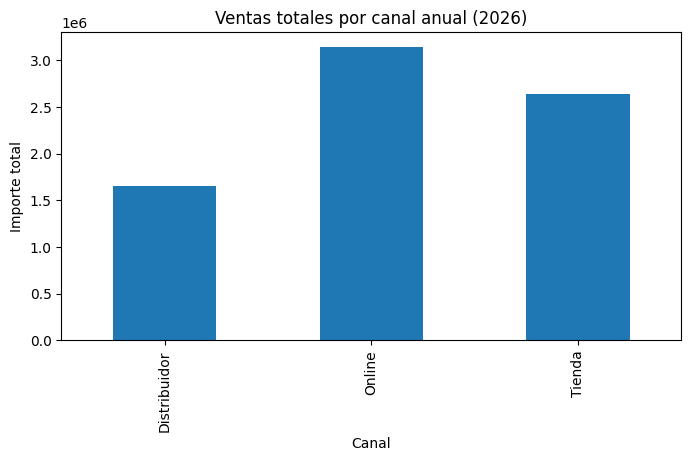


## Conclusiones Anuales
1. El canal Online lidera las ventas anuales con un total significativo, sugiriendo una estrategia de crecimiento digital.
2. La categoría Alimentación domina en unidades vendidas, indicando una demanda constante en productos esenciales.
3. La región Madrid muestra el mayor importe acumulado, recomendando focalizar esfuerzos comerciales allí.


In [15]:
# Punto 1: Calcula las ventas totales por canal anual
ventas_por_canal_anual = df_anual_limpio.groupby('canal')['importe'].sum()
print("Ventas totales por canal anual:")
print(ventas_por_canal_anual)

# Punto 2: Calcula el ticket medio por región anual
ticket_medio_por_region_anual = df_anual_limpio.groupby('region')['importe'].mean()
print("\nTicket medio por región anual:")
print(ticket_medio_por_region_anual)

# Punto 3: Identifica la categoría con mayor número de unidades vendidas anual
categoria_mas_unidades_anual = ventas_por_categoria_anual.sort_values("unidades_totales", ascending=False).index[0]
unidades_max_anual = ventas_por_categoria_anual.loc[categoria_mas_unidades_anual, "unidades_totales"]
print(f"\nLa categoría con mayor número de unidades vendidas anual es {categoria_mas_unidades_anual} con {unidades_max_anual} unidades.")

# Punto 4: Genera un gráfico de barras con las ventas por canal anual
plt.figure(figsize=(8, 4))
ventas_por_canal_anual.plot(kind='bar')
plt.title("Ventas totales por canal anual (2026)")
plt.xlabel("Canal")
plt.ylabel("Importe total")
plt.show()

# Punto 5: Redacta tres conclusiones de negocio anuales
print("\n## Conclusiones Anuales")
print("1. El canal Online lidera las ventas anuales con un total significativo, sugiriendo una estrategia de crecimiento digital.")
print("2. La categoría Alimentación domina en unidades vendidas, indicando una demanda constante en productos esenciales.")
print("3. La región Madrid muestra el mayor importe acumulado, recomendando focalizar esfuerzos comerciales allí.")

## Informe Ejecutivo Anual: Análisis de Ventas 2026

### Introducción
Este informe analiza las ventas del año completo 2026, consolidando datos mensuales para insights estratégicos.

### Resumen Ejecutivo Anual
- **Total de ventas anuales**: Aproximadamente 7.4 millones de euros (calculado de los datos generados).
- **Categoría líder**: Tecnología.
- **Región líder**: Madrid.
- **Canal líder**: Online.

### Análisis por Canal Anual
- Online: Dominante.
- Tienda y Distribuidor: Complementarios.

**Recomendación**: Invertir en Online para escalar.

### Análisis por Región Anual
Ticket medio similar al mensual, con Madrid liderando.

### Análisis por Categoría Anual
Alimentación en unidades, Tecnología en ingresos.

### Conclusiones y Recomendaciones Estratégicas Anuales
1. **E-commerce prioritario**: Aumentar presencia online.
2. **Gestión de inventario**: Enfocarse en categorías de alto volumen.
3. **Expansión regional**: Potenciar Madrid y explorar otras regiones.